# Demo: setting up ACCESS-rOM3

When using regional-mom6 as a standalone package, the user must provide the executable and forcing files before they can run the model itself. The regional ACCESS ocean model, rOM3, is a configuration of regional-mom6 supported by ACCESS-NRI, whereby ACCESS-NRI maintains an executable and forcing datasets on NCI (Australia's national HPC system), allowing users with access to run their models out of the box.


This demo serves as a starting point for all users who want to run ACCESS-rOM3, and ought to run out of the box for anyone on NCI with access to the correct projects. These are:

*TODO: add a table with all required projects. Where possible, consolidate projects - e.g., can I move the tassie glorys data somewhere else?*

Since this demo is necessarily hardcoded for NCI paths and environments, users outside of Australia should look instead at the machine-agnostic demo, or [CROCODILE-CESM](https://github.com/CROCODILE-CESM/) for users in the US.

## Preamble: Load packages and define workspace paths

To make sure that things are working we recommend starting with the default example defined below.

If this runs ok, then we can change to a domain of our choice and hopefully it runs ok too! If not, check the [README](https://github.com/COSIMA/regional-mom6/blob/main/README.md) and [documentation](https://regional-mom6.readthedocs.io/) for troubleshooting tips.

We can log in and use [Copernicus GUI](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/download) to find the latitude-longitude ranges of the domain of choice and then paste below.

In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt
from pathlib import Path
from dask.distributed import Client

#! ADD DEV VERSIONS OF RMOM6. This won't be needed if we can get a proper environment that's available on ARE sessions on gadi
import sys
sys.path.insert(0, '/home/149/ab8992/regional-mom6/regional-mom6')
sys.path.insert(0, '/home/149/ab8992/regional-mom6/crocodile/mom6_forge')
#!
import regional_mom6 as rmom6
print("using regional-mom6 version " + rmom6.__version__)
client = Client(threads_per_worker = 1)


expt_name = "sanity-check-rom3"
project = os.environ["PROJECT"]
#! Override for testing
project="nm03"
user = os.environ["USER"]
scratch = Path(f"/g/data/{project}/{user}")
gdata = Path(f"/g/data/{project}/{user}")

## Place where all the input files go
input_dir = f"{gdata}/rom3-inputdirs/{expt_name}/"

## Directory where we'll be running the experiment from
run_dir = f"{gdata}/rom3-rundirs/{expt_name}/"

## Directory for temporary files we don't need long term
tmp_dir = f"{scratch}/tmp/{expt_name}"

## if directories don't exist, create them
for path in (run_dir, tmp_dir, input_dir):
    os.makedirs(str(path), exist_ok=True)

using regional-mom6 version 1.0.2.dev2+gadae56d15


## Step 1: Define your experiment

The experiment object, which we've called `expt` below, is the most important part of the `regional-mom6` workflow. It keeps track of everything about your experiment. 
In the next cell, we initialise the experiment object with all of the fundamental things that define our domain. Note that specific details like what datasets to use for the bathymetry or forcing aren't included here- this comes later. 

To make sure that things are working we recommend starting with the default example defined below.

If this runs ok, then we can change to a domain of our choice and hopefully it runs ok too! If not, check the [README](https://github.com/COSIMA/regional-mom6/blob/main/README.md) and [documentation](https://regional-mom6.readthedocs.io/) for troubleshooting tips.

We can log in and use [Copernicus GUI](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/download) to find the latitude-longitude ranges of the domain of choice and then paste below.


In [2]:
expt = rmom6.experiment(
    longitude_extent = [143, 150],                  # The extremes of your domain. Note that MOM6's c grid means that the tracer grid (like for bathymetry) will actually be slightly smaller than this               
    latitude_extent = [-48, -38.95],                
    date_range = ["2012-01-01", "2012-02-01"],      # This will set the start date of the experiment, and ensure we download the right forcing data 
    resolution = 0.1,                               # Horizontal resolution in degrees. This sets the zonal resolution - under the default grid, the meridional resolution is scaled to give a `square` grid when measured in km rather than degrees.
    hgrid_type="even_spacing",                      # Type of horizontal grid. Even spacing is the default - check out documentation and other demos for more information about grids.
    number_vertical_layers = 75,                    # Number of vertical layers, not number of interfaces.
    layer_thickness_ratio = 25,                     # Ratio of the deepest layer thickness to the surface layer. Set higher for more resolution near the surface. Negative values mean there's higher resolution at the sea floor
    depth = 4500,                                   # Maximum depth of your domain. This will set the depth of the deepest layer in the vertical coordinate. Best to have this match the deepest point in your bathymetry, but it doesn't have to.
    minimum_depth = 10,                             # Minimum depth of your domain. Shallower water will be considered land and masked out.
    tidal_constituents=[],                          # You can put your favourite tidal consituents here (e.g. "M2") or remove this line to turn on all of them (the default behaviour)
    mom_run_dir = run_dir,                          # This is the directory from which you will run your experiment. Namelists and other text files go here
    mom_input_dir = input_dir,                      # The location for all the data files needed for your experiment. netcdfs go here. 
    boundaries=["north", "south", "east", "west"]   # The boundaries and their orientations. Rectangular domains are easiest, but see documentation and other demos to see how to set up more complex domains
)

After running this step, have a look in the `input_dir` and you'll see that it's started being populated. We now have a horizontal grid (hgrid) and a vertical coordinate (vcoord). These two files are the main building blocks of the experiment. Now, everything else will be regridded to match these grids. 

You can also access and plot these grids directly using the expt object, since these variables are all stored internally as xarray objects

Tracer longitudes (tlon's) in our grid: 
 [143.05 143.15 143.25 143.35 143.45 143.55 143.65 143.75 143.85 143.95
 144.05 144.15 144.25 144.35 144.45 144.55 144.65 144.75 144.85 144.95
 145.05 145.15 145.25 145.35 145.45 145.55 145.65 145.75 145.85 145.95
 146.05 146.15 146.25 146.35 146.45 146.55 146.65 146.75 146.85 146.95
 147.05 147.15 147.25 147.35 147.45 147.55 147.65 147.75 147.85 147.95
 148.05 148.15 148.25 148.35 148.45 148.55 148.65 148.75 148.85 148.95
 149.05 149.15 149.25 149.35 149.45 149.55 149.65 149.75 149.85 149.95]

Velocity longitudes (ulat's) in our grid: 
 [143.  143.1 143.2 143.3 143.4 143.5 143.6 143.7 143.8 143.9 144.  144.1
 144.2 144.3 144.4 144.5 144.6 144.7 144.8 144.9 145.  145.1 145.2 145.3
 145.4 145.5 145.6 145.7 145.8 145.9 146.  146.1 146.2 146.3 146.4 146.5
 146.6 146.7 146.8 146.9 147.  147.1 147.2 147.3 147.4 147.5 147.6 147.7
 147.8 147.9 148.  148.1 148.2 148.3 148.4 148.5 148.6 148.7 148.8 148.9
 149.  149.1 149.2 149.3 149.4 149.5 149.6 149.7 1

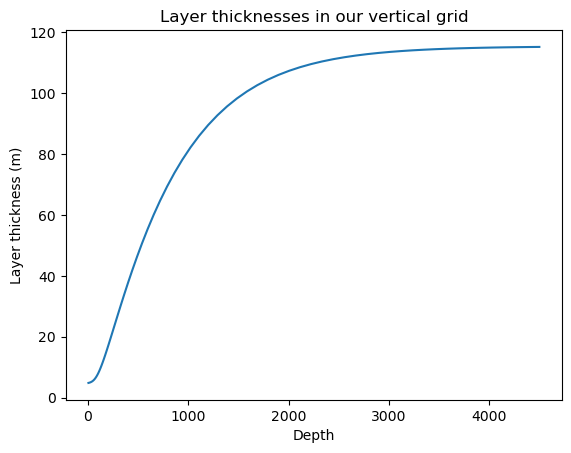

In [5]:
print("Tracer longitudes (tlon's) in our grid: \n",expt.grid.tlon.values[0,:],end = "\n\n")
print("Velocity longitudes (ulat's) in our grid: \n",expt.grid.ulon.values[0,:],end = "\n\n")
print("Interface heights in our vertical grid: \n",expt.vgrid.zi.values.round(1),end = "\n\n")

# Plot the layer thicknesses by calculating the difference between the interface heights
expt.vgrid.zi.diff("zi").plot()
plt.title("Layer thicknesses in our vertical grid"), plt.xlabel("Depth") , plt.ylabel("Layer thickness (m)");


## Step 2: Download forcing data for your domain
### OR use the Tasmania data we prepared earlier for the demo

*If you're just running this notebook as is, you don't need to download the Tassie forcing data since we did it for you! But you will need this step when running a new domain*

We use the glorys reanalysis product to make the initial condition and boundary forcing files for rOM3. These files can be downloaded from the Copernicusmarine database, but you'll need to make an account here first. 

The method below generates a bash script for downloading the initial conditions and boundary forcing data required for your experiment. Once you run the next cell, you'll need to go to your `tmp` directory (that was defined above, usually in your scratch space), and run the `get_glorys.sh` script. It's best if you start an interactive copyq job for this, as downloads can be large for big domains.


In [13]:
# If you're running your own experiment in a new domain, run this cell
expt.get_glorys(tmp_dir)

The script `get_glorys_data.sh` has been generated at:
  /g/data/ol01/rOM3-dev/tassie-demo-forcing.
To download the data, run this script using `bash` in a terminal with internet access.

Important instructions:
1. You will need your Copernicus Marine username and password.
   If you do not have an account, you can create one here: 
   https://data.marine.copernicus.eu/register
2. You will be prompted to enter your Copernicus Marine credentials multiple times: once for each dataset.
3. Depending on the dataset size, the download process may take significant time and resources.
4. Thus, on certain systems, you may need to run this script as a batch job.



In [14]:
# If you're just using the Tasmania domain for the demo, run this cell to overwrite the `tmp_dir` 
# with one containing the Tassie data you need
tmp_dir = "/g/data/ol01/rOM3-dev/tassie-demo-forcing"

Either way, after finishing this step, your `tmp_dir` should now have five files: `east_unprocessed.nc`, `west_unprocessed.nc`, `north_unprocessed.nc`, `south_unprocessed.nc` and `ic_unprocessed.nc`. These files don't have to come from GLORYS - you can easily construct them yourself from your favourite forcing dataset. For example, you could use the COSIMA intake catalogue to subset ACCESS-OM2 model data outputs to serve as your forcind data, or even output from another regional MOM6 domain to make a inner, higher resolution nested experiment. 

All you need to do is cut out your desired forcing dataset and make skinny (5 grid cells wide) boundary segment files for the duration of your experiment, and one initial condition file. Name them the same as above, and put them in your `tmp_dir`. 

## 3. Set up bathymetry & forcing files

Now that we have our main experiment object defined, we get it to do all the heavy lifting. Here, just need feed it the path to our bathymetry file of choice, and tell it what the coordinates are called. 

In [12]:
expt.setup_bathymetry(
    bathymetry_path='/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc',
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='elevation',
    )

Setting up bathymetry...if this fails, please follow the printed instructions with your experiment topo object, like this: [experiment_obj].topo. For example, if the output tells you to run mpi_set_from_dataset instead of set_from_dataset. You would do: [experiment_obj].topo.mpi_set_from_dataset(...)
**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Begin regridding dataset...

Original dataset size: 37.08 Mb
Regridded size: 0.21 Mb

Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

<xarray.Dataset> Size: 245kB
Dimensions:  (ny: 125, nx: 70)
Dimensions without coordinates: ny, nx
Data variables:
    y        (ny, nx) float64 70kB -47.96 -47.96 -47.96 ... -38.99 -38.99 -38.99
    x        (ny, nx) float64 70kB 143.1 143.2 143.2 143.3 ... 149.8 149.8 149.9
    mask     (ny, nx) int32 35kB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    depth    (ny, nx) float64 70kB 4.566e+03 4.424e+03 ... 4.041e+03 4.324e+03
Attributes:
    date_created:  2026-04-22T15:53:20.203837
    title:         MOM6 topography file
    min_depth:     0.0
    max_depth:     5104.307968237768

Now if you look in the `input_dir`, you'll see a `bathymetry.nc` file. There's also an intermediate file called `bathymetry_raw.nc`. This is a file that's been cut out but not yet regridded - important if you need to do your regridding as a separate job with extra resources, but don't worry about that for now. 

Just like with the grids above, we can directly plot the bathymetry now:

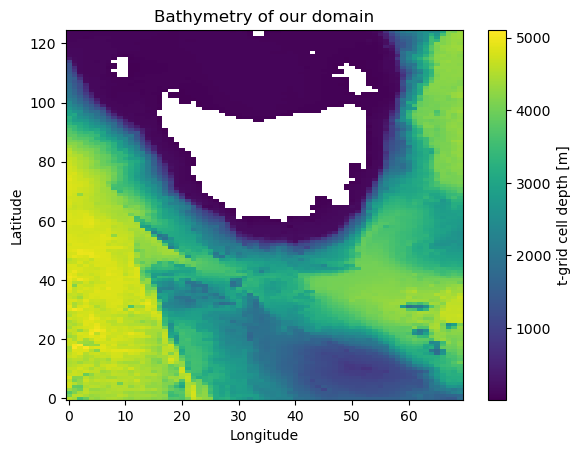

In [7]:
# To add a land mask to the domain, it's easy to just use the .where method to only plot the points where the bathymetry is not zero
expt.bathymetry.depth.where(expt.bathymetry.depth != 0).plot()
plt.title("Bathymetry of our domain"), plt.xlabel("Longitude") , plt.ylabel("Latitude");

Next, we pass on the paths to the initial and boundary conditions. These are the GLORYS files that we downloaded earlier to our `tmp_dir`. 

Importantly, if you didn't want to force with GLORYS data, you'll need to modify the`ocean_varnames` dictionary that maps the MOM6 variable names (`yh`, `xh` etc.) to the variable names in the dataset. 

The last thing you need to do is specify which Arakawa grid your input data is on. In the case of the GLORYS dataset, tracers and velocities are on the same grid points, so it's an "A" grid. 

In [16]:
# Mapping dictionary between MOM6 variable names (left) and those in GLORYS (right), which is the source dataset for the forcing files
# If you use a different source dataset, simply replace the GLORYS names with those in your dataset of choice

ocean_varnames = {"time": "time",
                  "yh": "latitude", 
                  "xh": "longitude",
                  "zl": "depth",
                  "eta": "zos",
                  "u": "uo",
                  "v": "vo",
                  "tracers": {"salt": "so", "temp": "thetao"} # You can have as many tracers here as you like, and they will all get regridded to your ICs / BCs
                  }

# Set up the initial condition.
expt.setup_initial_condition(
    tmp_dir + "/ic_unprocessed.nc",
    ocean_varnames,
    arakawa_grid = "A"
    )

# Set up the four boundary conditions.
expt.setup_ocean_state_boundaries(
    Path(tmp_dir),
    ocean_varnames,
    arakawa_grid = "A"
    )

INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.utils:Units for eta did not need to be converted


Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.regridding:Getting t points..
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Getting u points..
INFO:regional_mom6.regridding:Getting v points..


Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... 

INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in salt_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to salt_segment_001
INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in temp_segment_001
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to temp_segment_001
INFO:regional_mom6.regridding:Renaming ver

...

Done.
Processing east boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.regridding:Renaming vertical coordinate to nz_... in v_segment_003
INFO:regional_mom6.regridding:Replacing old depth coordinates with incremental integers
INFO:regional_mom6.regridding:Adding perpendicular dimension to v_segment_003
INFO:regional_mom6.utils:Units for eta did not need to be converted
INFO:regional_mom6.regridding:Adding perpendicular dimension to eta_segment_003
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Generating encoding dictionary
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.utils:Units for depth did not need to be converted
INFO:regional_mom6.regridding:Creating Regridder
INFO:regional_mom6.rotation:Getting rotation angle
INFO:regional_mom6.rotation:Calculating grid rotation angle
INFO:regional_mom6.regridding:Creating coordinates of the boundary q/u/v points
INFO:regional_mom6.regridding:Adding time dimension
INFO:regional

Done.
Processing west boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid


INFO:regional_mom6.utils:Units for eta did not need to be converted
INFO:regional_mom6.regridding:Adding perpendicular dimension to eta_segment_004
INFO:regional_mom6.regridding:Filling in missing data horizontally, then vertically
INFO:regional_mom6.regridding:Generating encoding dictionary


Done.


In [31]:
expt.bathymetry.mask

<xarray.DataArray 'mask' (ny: 125, nx: 70)> Size: 35kB
[8750 values with dtype=int32]
Dimensions without coordinates: ny, nx
Attributes:
    long_name:  landsea mask at t points: 1 ocean, 0 land
    units:      nondim

In [32]:
expt.init_velocities.u

<xarray.DataArray 'u' (zl: 75, ny: 125, nxp: 71)> Size: 5MB
[665625 values with dtype=float64]
Coordinates:
  * zl       (zl) float64 600B 2.411 7.252 12.13 ... 4.327e+03 4.442e+03
  * ny       (ny) int64 1kB 1 3 5 7 9 11 13 15 ... 237 239 241 243 245 247 249
  * nxp      (nxp) int64 568B 0 2 4 6 8 10 12 14 ... 128 130 132 134 136 138 140
Attributes:
    _FillValue:     9.969209968386869e+36
    cell_methods:   area: mean
    long_name:      Eastward velocity
    standard_name:  eastward_sea_water_velocity
    unit_long:      Meters per second
    units:          m s-1
    valid_max:      4314
    valid_min:      -3123
    coordinates:    xq yh

Now we've made our initial and boundary conditions, these files are also now in our `input_dir`. The initial conditions can also be plotted via our experiment object. Remember that calling `expt.init_tracers` just returns an xarray object, so everything from there on is just xarray syntax

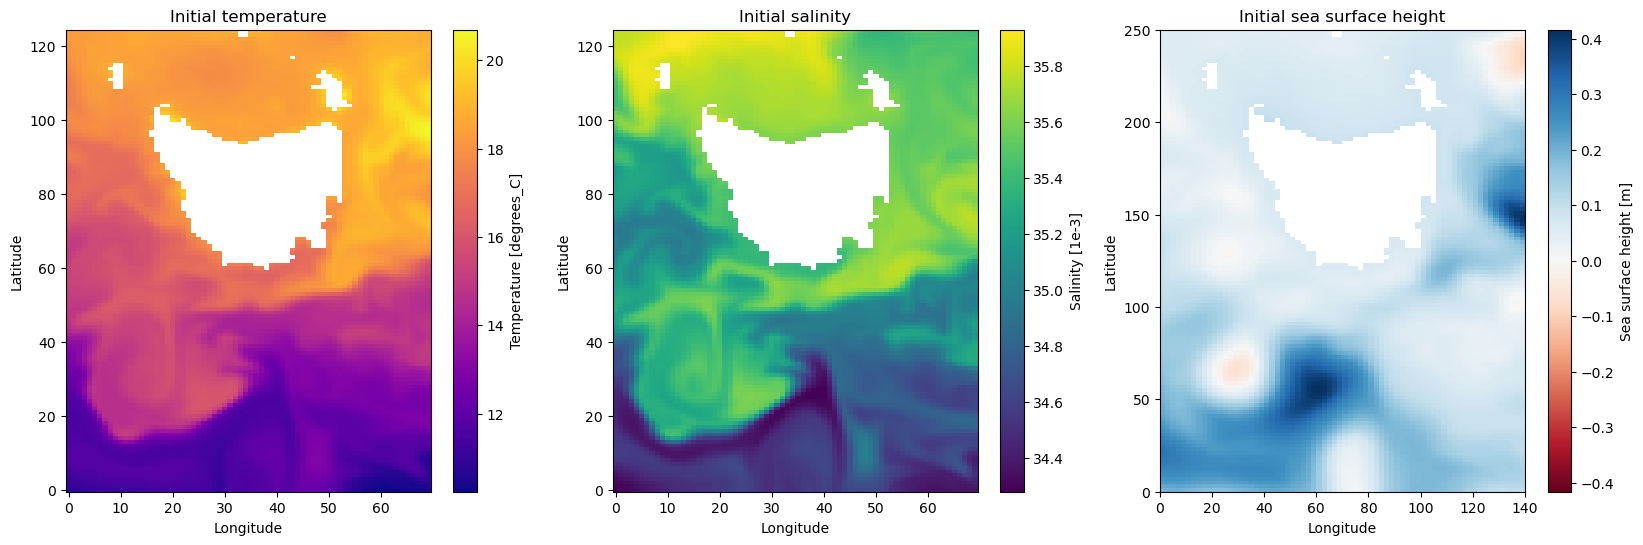

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(20, 6))
# Plot the surface values of temperature, salinity and sea surface height for the initial conditions
expt.init_tracers.temp.isel(zl = 0).where(expt.bathymetry.depth != 0).plot(ax=ax[0],cmap = "plasma")
expt.init_tracers.salt.isel(zl = 0).where(expt.bathymetry.depth != 0).plot(ax=ax[1])
expt.init_eta.eta_t.where(expt.bathymetry.depth != 0).plot(ax=ax[2],cmap = "RdBu")
ax[0].set_title("Initial temperature"), ax[1].set_title("Initial salinity"), ax[2].set_title("Initial sea surface height")
for i in ax:
    i.set_xlabel("Longitude"), i.set_ylabel("Latitude")

## 4. Set up the run directory

So far, each of the methods we've run have populated the `input_dir` with data files, like the grids, bathymetry, forcing files etc. The last step is to set up the run directory with the text files that the model needs. These include the `diag_table`, `MOM_input` and `MOM_override` files for MOM6, the `nuopc.runconfig` for the nuopc coupler, and the `config.yaml` file for payu. 

This final step uses all of the information that `regional-mom6` knows about your experiment to write out these files, creating a run directory that's ready to be run with the `payu` scheduler. 

In [10]:
expt.setup_rOM3()

Added MINIMUM_DEPTH to MOM_override with value {'value': 10.0, 'override': True, 'comment': None}
Added NK to MOM_override with value {'value': 75, 'override': True, 'comment': None}
Added NIGLOBAL to MOM_override with value {'value': 70, 'override': True, 'comment': None}
Added NJGLOBAL to MOM_override with value {'value': 125, 'override': True, 'comment': None}
Added AUTO_MASKTABLE to MOM_override with value {'value': True, 'override': True, 'comment': None}
Added OBC_NUMBER_OF_SEGMENTS to MOM_override with value {'value': 4, 'override': True, 'comment': None}
Added OBC_FREESLIP_VORTICITY to MOM_override with value {'value': 'False', 'override': True, 'comment': None}
Added OBC_FREESLIP_STRAIN to MOM_override with value {'value': 'False', 'override': True, 'comment': None}
Added OBC_COMPUTED_VORTICITY to MOM_override with value {'value': 'True', 'override': True, 'comment': None}
Added OBC_COMPUTED_STRAIN to MOM_override with value {'value': 'True', 'override': True, 'comment': None}

## 5. Run with payu

This step takes place in a terminal on gadi inside your run directory. 

1. load payu with

    `module use /g/data/vk83/modules; module load payu`

2. Set up the experiment:

    `payu setup`

2. Run the experiment

    `payu run -f`
